# 1. Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


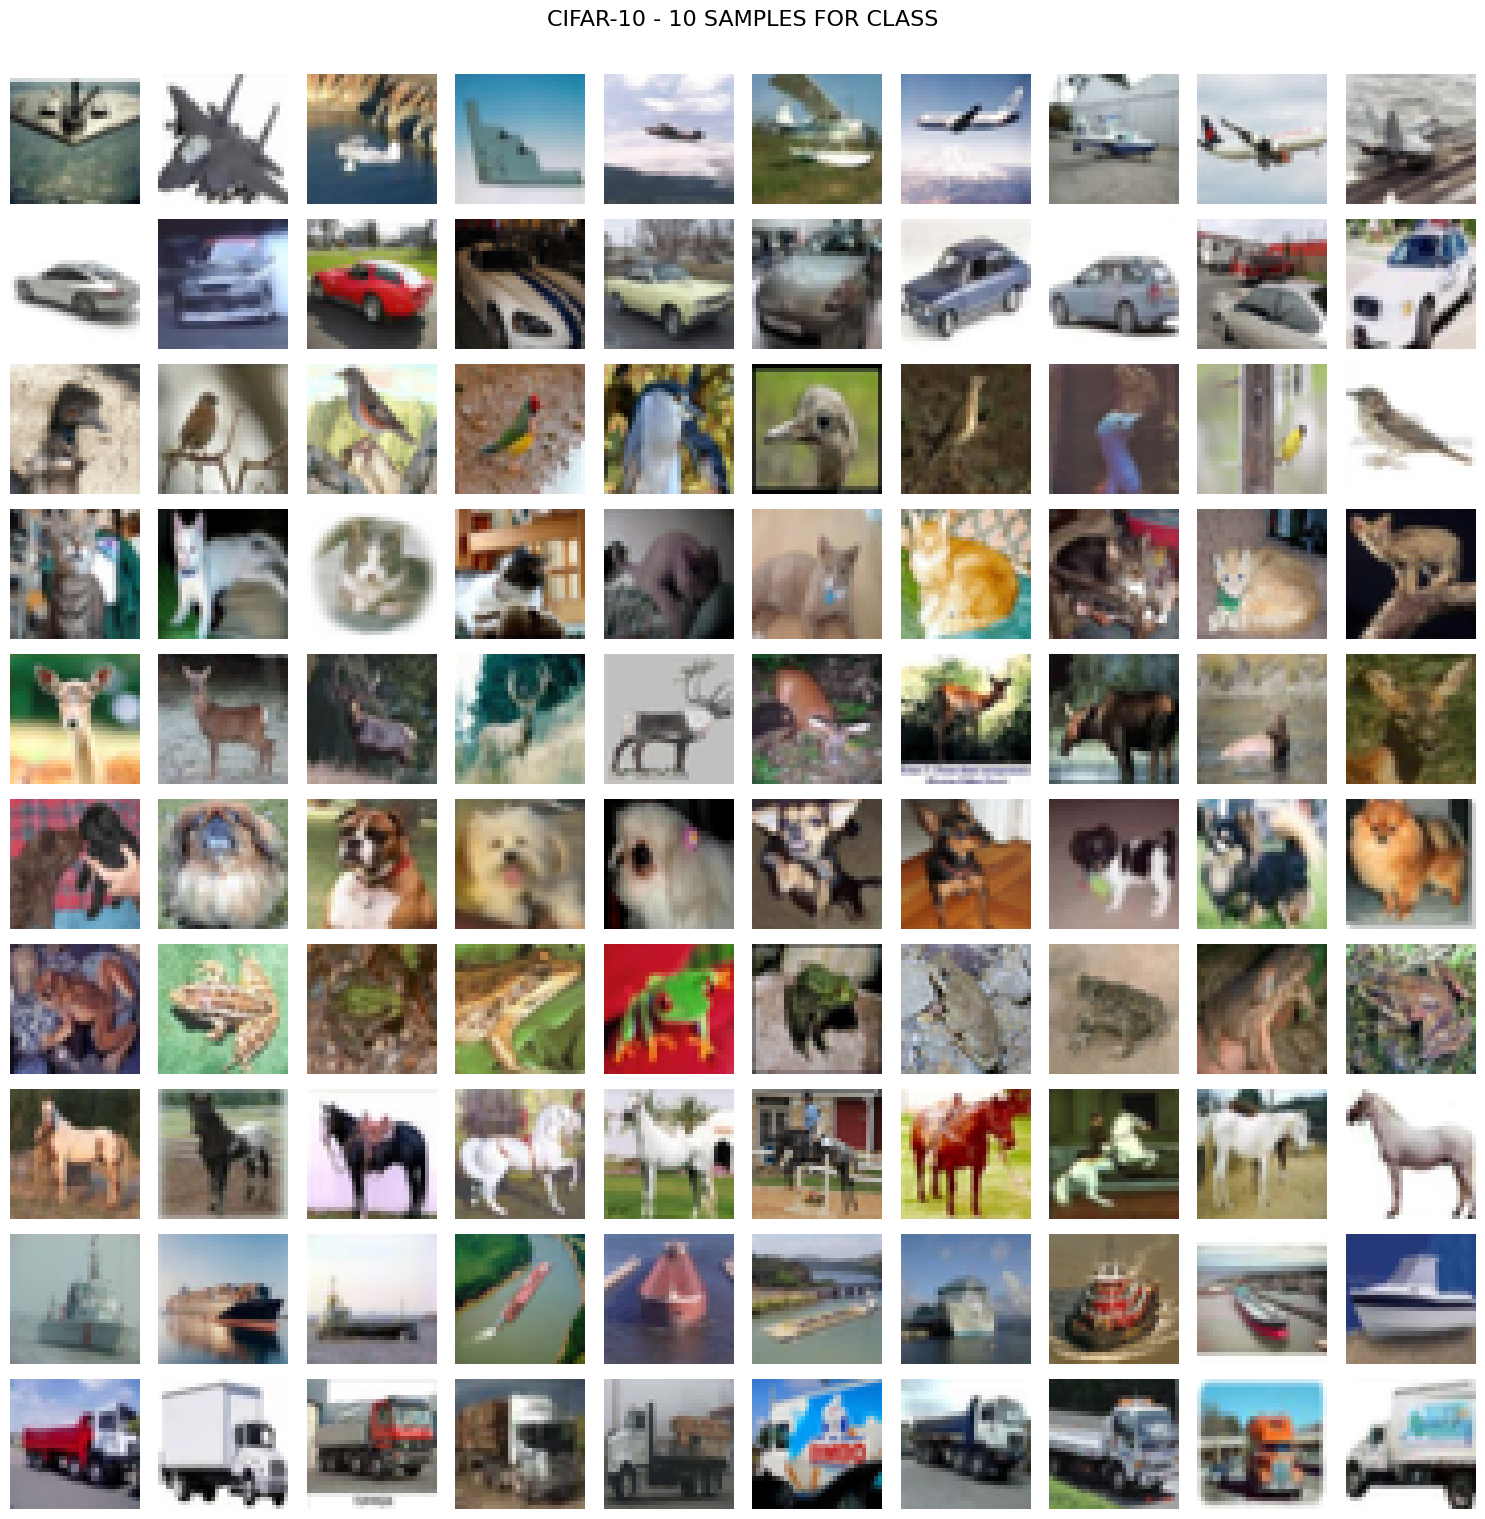

shape labels before: (50000, 1)  ->depois: (50000, 10)
pixel min= 0.0 pixel max= 1.0


In [2]:
class_names = ['airplane', 'automoblie', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#visualize 10x10
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('CIFAR-10 - 10 SAMPLES FOR CLASS', fontsize=16, y=1.01)

for class_idx in range(10):
  indices = np.where(y_train.flatten() == class_idx)[0]
  samples = np.random.choice(indices, 10, replace=False)
  for col, sample_idx in enumerate(samples):
    ax = axes[class_idx, col]
    ax.imshow(x_train[sample_idx])
    ax.axis('off')
    if col == 0:
      ax.set_ylabel(class_names[class_idx], fontsize=9, rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.show()

# one-hot encode
y_train_Cat = to_categorical(y_train, num_classes=10)
y_test_Cat = to_categorical(y_test, num_classes=10)
print('shape labels before:', y_train.shape, ' ->depois:', y_train_Cat.shape)

#normalize
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
print('pixel min=', x_train_norm.min(), 'pixel max=', x_train_norm.max())


# 2. Model Architecture  

In [3]:
from keras.backend import clear_session
clear_session()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

#model 4
model4 = Sequential([
    # --- Block 1 ---
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # 32x32 → 16x16

    # --- Block 2 ---
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),  # 16x16 → 8x8

    # --- Block 3 ---
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # 8x8 → 4x4

    # --- Classifier head ---
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,158 (1.14 MB)

 Trainable params: 299,158 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Training (Learning rate = 0.0005)

In [5]:
from sklearn.model_selection import train_test_split

# 90/10 train/validation split
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train_norm, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Training samples:   {x_train_split.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")

Training samples:   45000
Validation samples: 5000


In [6]:
from tensorflow.keras.optimizers import Adam

model4.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model4.fit(
    x_train_split, y_train_split,
    epochs=50,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.2800 - loss: 1.9248 - val_accuracy: 0.3954 - val_loss: 1.6281
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3585 - loss: 1.7235 - val_accuracy: 0.4286 - val_loss: 1.5947
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3881 - loss: 1.6637 - val_accuracy: 0.4592 - val_loss: 1.4786
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4037 - loss: 1.6197 - val_accuracy: 0.4214 - val_loss: 1.5693
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4184 - loss: 1.5889 - val_accuracy: 0.4178 - val_loss: 1.6234
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4251 - loss: 1.5679 - val_accuracy: 0.4628 - val_loss: 1.4519
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4338 - loss: 1.5431 - val_accuracy: 0.4960 - val_loss: 1.3870
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4431 - loss: 1.5262 - val_accuracy: 

# 4. Performance

Final Training Loss:     1.4333
Final Training Accuracy: 48.91%
Validation Loss:         1.2616
Validation Accuracy:     54.76%
Test Loss:               1.2781
Test Accuracy:           54.97%


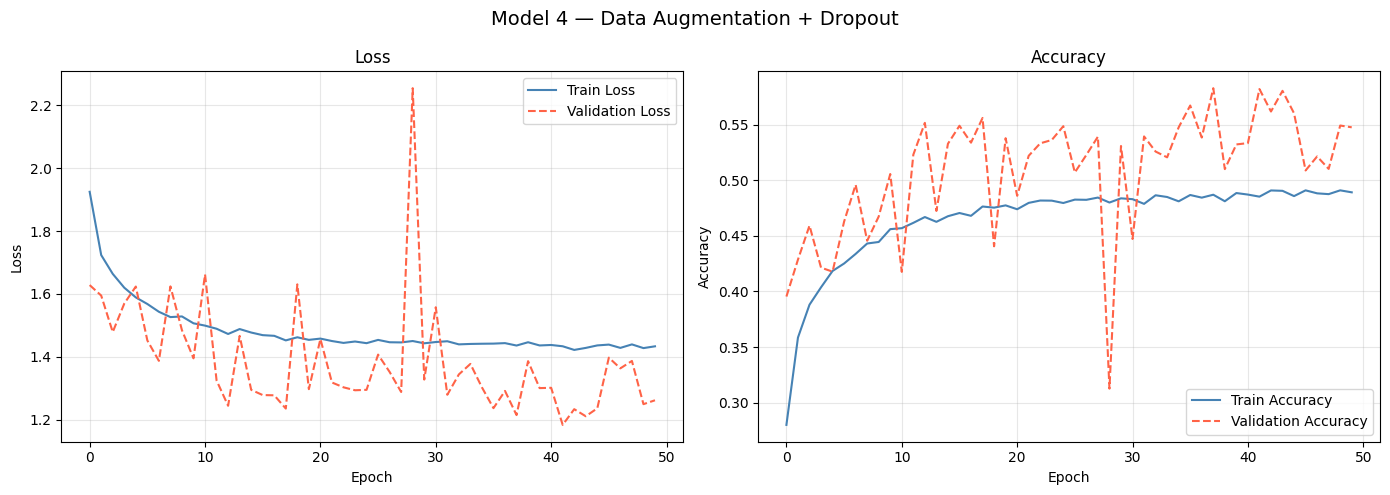

In [7]:
# ── Evaluate ──────────────────────────────────────────
val_loss7,  val_acc7  = model4.evaluate(x_val,       y_val,  verbose=0)
test_loss7, test_acc7 = model4.evaluate(x_test_norm, y_test, verbose=0)

print(f"Final Training Loss:     {history.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Loss:         {val_loss7:.4f}")
print(f"Validation Accuracy:     {val_acc7*100:.2f}%")
print(f"Test Loss:               {test_loss7:.4f}")
print(f"Test Accuracy:           {test_acc7*100:.2f}%")

# ── Training Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 4 — Data Augmentation + Dropout', fontsize=14)

axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

    airplane       0.68      0.55      0.61       500
  automoblie       0.88      0.62      0.73       500
        bird       0.41      0.38      0.39       500
         cat       0.31      0.51      0.39       500
        deer       0.40      0.64      0.49       500
         dog       0.56      0.14      0.22       500
        frog       0.51      0.72      0.60       500
       horse       0.77      0.53      0.62       500
        ship       0.75      0.70      0.73       500
       truck       0.68      0.68      0.68       500

    accuracy                           0.55      5000
   macro avg       0.59      0.55      0.55      5000
weighted avg       0.59      0.55      0.55      5000



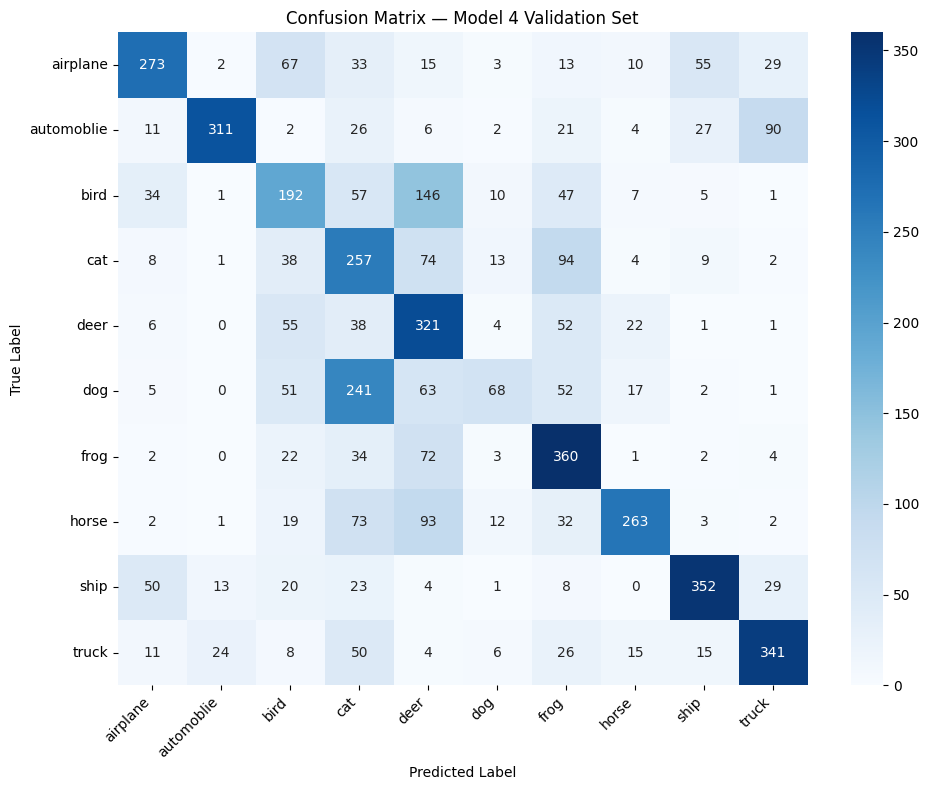

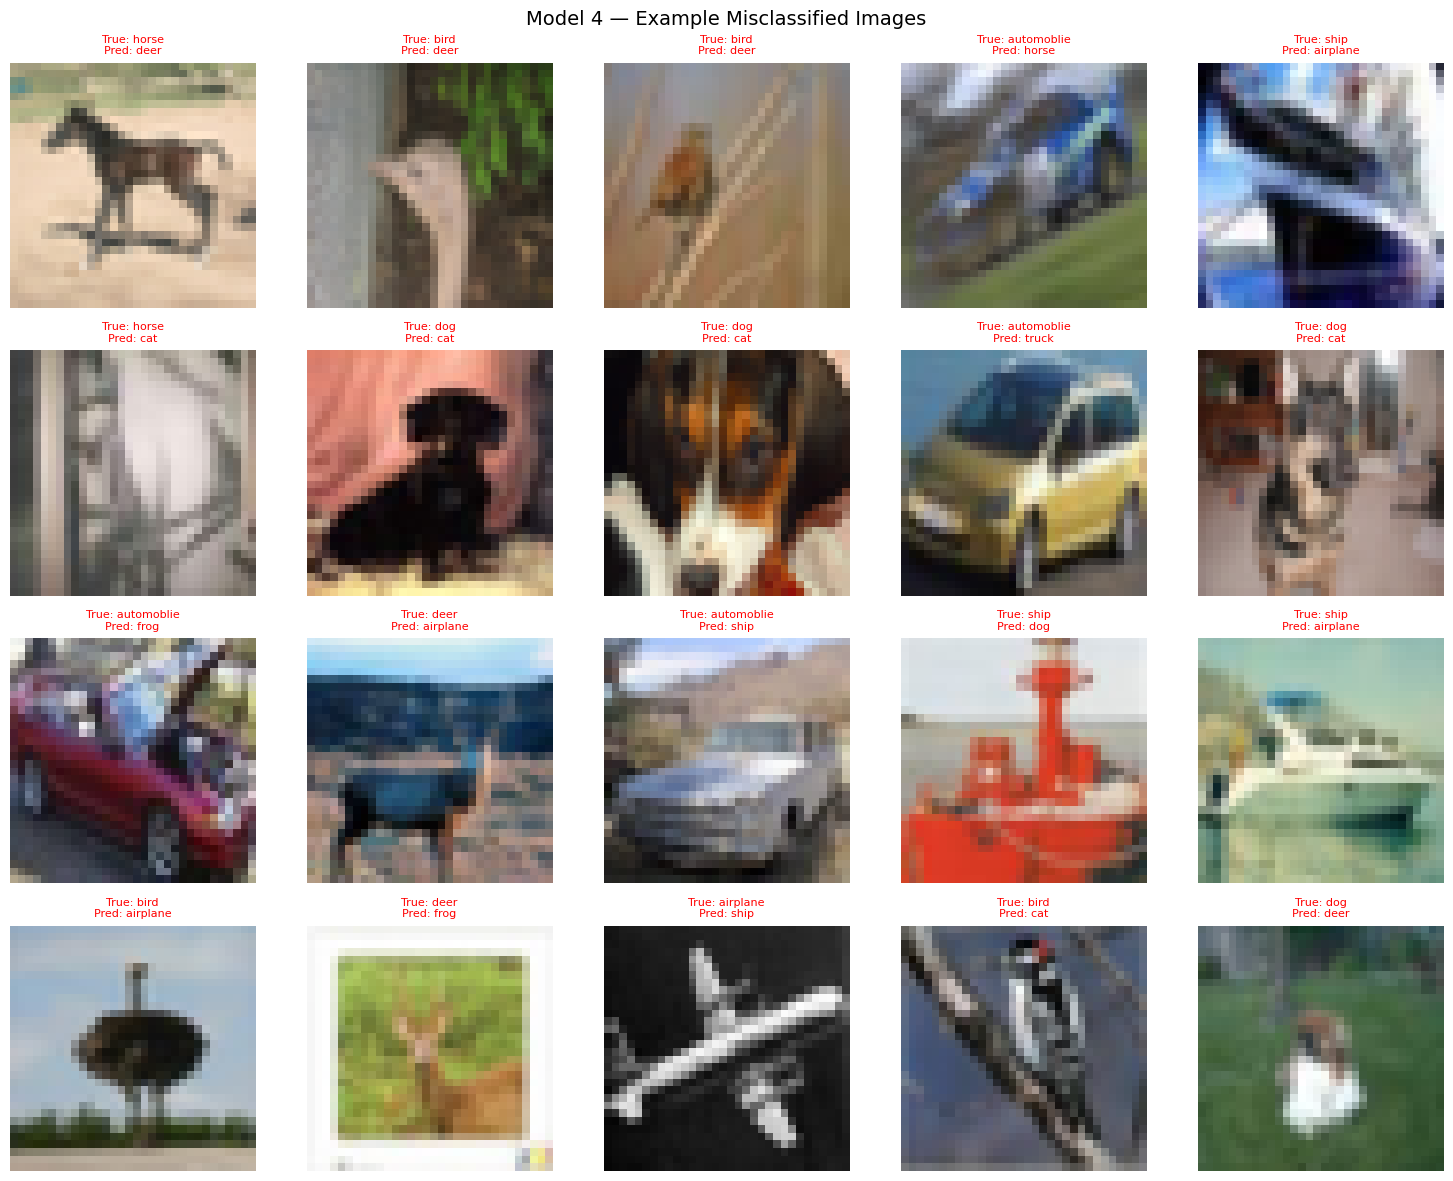

Total misclassified: 2262 / 5000


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## ── Classification Report & Confusion Matrix ──────────
y_val_pred7  = np.argmax(model4.predict(x_val), axis=1)
y_val_true   = y_val.flatten()                # ← plain integers, no argmax needed

print(classification_report(y_val_true, y_val_pred7, target_names=class_names))

cm7 = confusion_matrix(y_val_true, y_val_pred7)
plt.figure(figsize=(10, 8))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Model 4 Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Misclassified Images ──────────────────────────────
errors = np.where(y_val_pred7 != y_val_true)[0]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Model 4 — Example Misclassified Images', fontsize=14)

for i, idx in enumerate(errors[:20]):
    ax = axes[i//5, i%5]
    ax.imshow(x_val[idx])
    ax.axis('off')
    ax.set_title(f'True: {class_names[y_val_true[idx]]}\nPred: {class_names[y_val_pred7[idx]]}',
                 fontsize=8, color='red')

plt.tight_layout()
plt.show()
print(f"Total misclassified: {len(errors)} / {len(y_val_true)}")